In [1]:
# import libraries
import torch
import numpy as np

In [2]:
from torchvision import datasets
import torchvision.transforms as transforms

# number of subprocesses to use for data loading
num_workers = 0
# how many samples per batch to load
batch_size = 20

# convert data to torch.FloatTensor
transform = transforms.ToTensor()

# choose the training and test datasets
train_data = datasets.MNIST(root='data', train=True,
                                   download=True, transform=transform)
test_data = datasets.MNIST(root='data', train=False,
                                  download=True, transform=transform)

# prepare data loaders
train_loader = torch.utils.data.DataLoader(
    train_data,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers
)

test_loader = torch.utils.data.DataLoader(
    test_data,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers
)

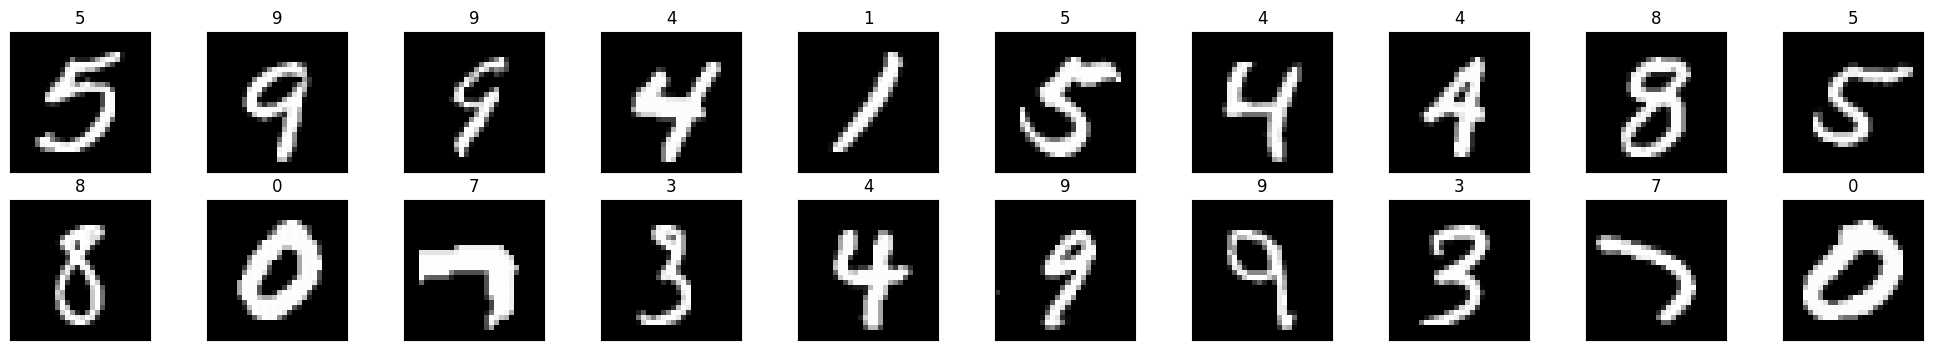

In [3]:
import matplotlib.pyplot as plt
%matplotlib inline

# obtain one batch of training images
dataiter = iter(train_loader)
images, labels = next(dataiter)
images = images.numpy()

# plot the images in the batch, along with the corresponding labels
fig = plt.figure(figsize=(25, 4))
for idx in np.arange(20):
    ax = fig.add_subplot(2, 10, idx+1, xticks=[], yticks=[])
    ax.imshow(np.squeeze(images[idx]), cmap='gray')
    # print out the correct label for each image
    # .item() gets the value contained in a Tensor
    ax.set_title(str(labels[idx].item()))

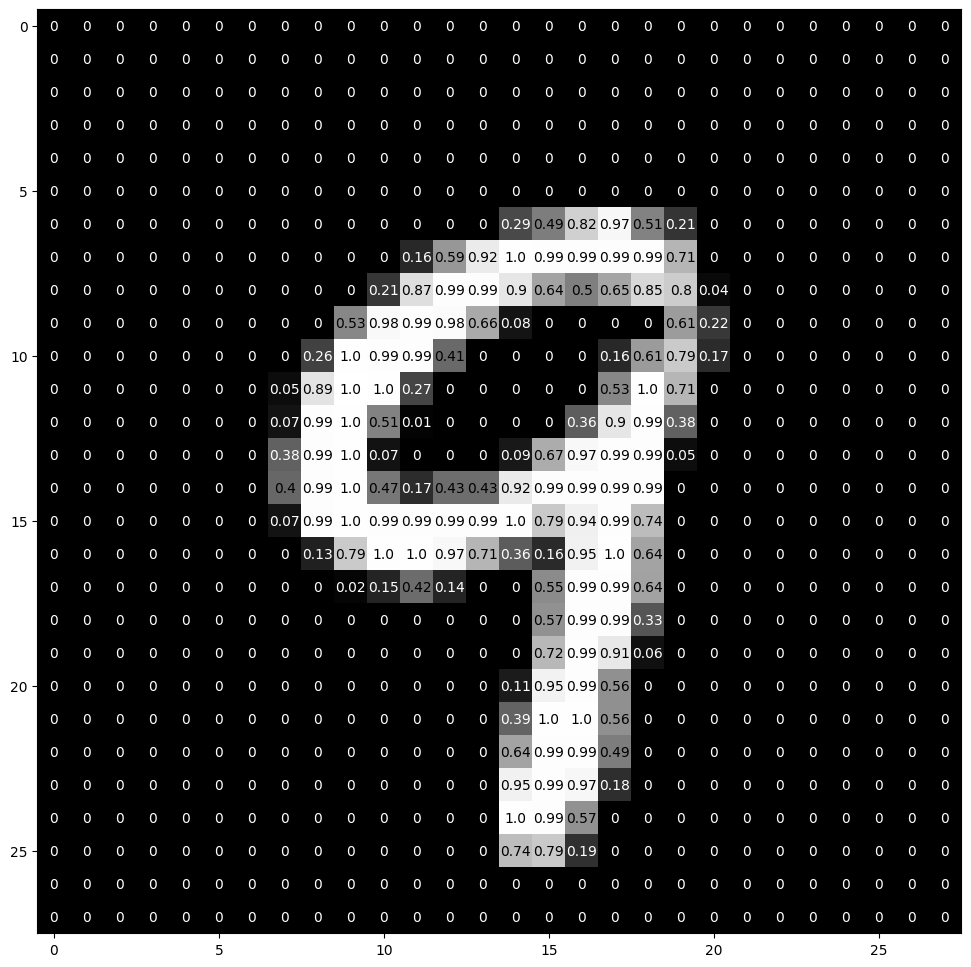

In [4]:
img = np.squeeze(images[1])

fig = plt.figure(figsize = (12,12))
ax = fig.add_subplot(111)
ax.imshow(img, cmap='gray')
width, height = img.shape
thresh = img.max()/2.5
for x in range(width):
    for y in range(height):
        val = round(img[x][y],2) if img[x][y] !=0 else 0
        ax.annotate(str(val), xy=(y,x),
                    horizontalalignment='center',
                    verticalalignment='center',
                    color='white' if img[x][y]<thresh else 'black')

In [5]:
import torch.nn as nn
import torch.nn.functional as F

## TODO: Define the NN architecture
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        # linear layers for MLP architecture
        self.fc1 = nn.Linear(28 * 28, 512)
        self.fc2 = nn.Linear(512, 512)
        self.fc3 = nn.Linear(512, 10)
        self.dropout = nn.Dropout(p=0.2)

    def forward(self, x):
        # flatten image input
        x = x.view(-1, 28 * 28)
        # add hidden layer, with relu activation function
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.dropout(F.relu(self.fc2(x)))
        x = self.fc3(x)
        return x

# initialize the NN
model = Net()
print(model)

Net(
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=512, bias=True)
  (fc3): Linear(in_features=512, out_features=10, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)


In [6]:
## TODO: Specify loss and optimization functions

# specify loss function
criterion = nn.CrossEntropyLoss()

# specify optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [7]:
# number of epochs to train the model
n_epochs = 30  # suggest training between 20-50 epochs

model.train() # prep model for training

for epoch in range(n_epochs):
    # monitor training loss
    train_loss = 0.0

    ###################
    # train the model #
    ###################
    for data, target in train_loader:
        # clear the gradients of all optimized variables
        optimizer.zero_grad()
        # forward pass: compute predicted outputs by passing inputs to the model
        output = model(data)
        # calculate the loss
        loss = criterion(output, target)
        # backward pass: compute gradient of the loss with respect to model parameters
        loss.backward()
        # perform a single optimization step (parameter update)
        optimizer.step()
        # update running training loss
        train_loss += loss.item()*data.size(0)

    # print training statistics
    # calculate average loss over an epoch
    train_loss = train_loss/len(train_loader.dataset)

    print('Epoch: {} \tTraining Loss: {:.6f}'.format(
        epoch+1,
        train_loss
        ))

Epoch: 1 	Training Loss: 0.224057
Epoch: 2 	Training Loss: 0.110792
Epoch: 3 	Training Loss: 0.085483
Epoch: 4 	Training Loss: 0.076606
Epoch: 5 	Training Loss: 0.063169
Epoch: 6 	Training Loss: 0.061294
Epoch: 7 	Training Loss: 0.054087
Epoch: 8 	Training Loss: 0.050138
Epoch: 9 	Training Loss: 0.048575
Epoch: 10 	Training Loss: 0.047919
Epoch: 11 	Training Loss: 0.044523
Epoch: 12 	Training Loss: 0.044801
Epoch: 13 	Training Loss: 0.040945
Epoch: 14 	Training Loss: 0.037844
Epoch: 15 	Training Loss: 0.040672
Epoch: 16 	Training Loss: 0.035848
Epoch: 17 	Training Loss: 0.040446
Epoch: 18 	Training Loss: 0.034000
Epoch: 19 	Training Loss: 0.043521
Epoch: 20 	Training Loss: 0.036659
Epoch: 21 	Training Loss: 0.037652
Epoch: 22 	Training Loss: 0.039518
Epoch: 23 	Training Loss: 0.034069
Epoch: 24 	Training Loss: 0.036374
Epoch: 25 	Training Loss: 0.033089
Epoch: 26 	Training Loss: 0.035679
Epoch: 27 	Training Loss: 0.035726
Epoch: 28 	Training Loss: 0.034008
Epoch: 29 	Training Loss: 0.0

In [8]:
test_loss = 0.0
class_correct = list(0. for i in range(10))
class_total = list(0. for i in range(10))

model.eval()

with torch.no_grad():
    for data, target in test_loader:
        output = model(data)
        loss = criterion(output, target)
        test_loss += loss.item()*data.size(0)

        _, pred = torch.max(output, 1)
        correct = pred.eq(target)

        for i in range(len(target)):
            label = target[i]
            class_correct[label] += correct[i].item()
            class_total[label] += 1

test_loss = test_loss / len(test_loader.dataset)
print('Test Loss: {:.6f}\n'.format(test_loss))

for i in range(10):
    if class_total[i] > 0:
        print('Test Accuracy of %5s: %2d%% (%2d/%2d)' % (
            str(i),
            100 * class_correct[i] / class_total[i],
            class_correct[i],
            class_total[i]))

Test Loss: 0.140916

Test Accuracy of     0: 99% (973/980)
Test Accuracy of     1: 99% (1127/1135)
Test Accuracy of     2: 98% (1012/1032)
Test Accuracy of     3: 98% (995/1010)
Test Accuracy of     4: 97% (958/982)
Test Accuracy of     5: 98% (875/892)
Test Accuracy of     6: 98% (947/958)
Test Accuracy of     7: 98% (1012/1028)
Test Accuracy of     8: 96% (942/974)
Test Accuracy of     9: 97% (981/1009)


In [9]:
print('\nTest Accuracy (Overall): %2d%% (%2d/%2d)' % (
    100. * np.sum(class_correct) / np.sum(class_total),
    np.sum(class_correct),
    np.sum(class_total)))


Test Accuracy (Overall): 98% (9822/10000)


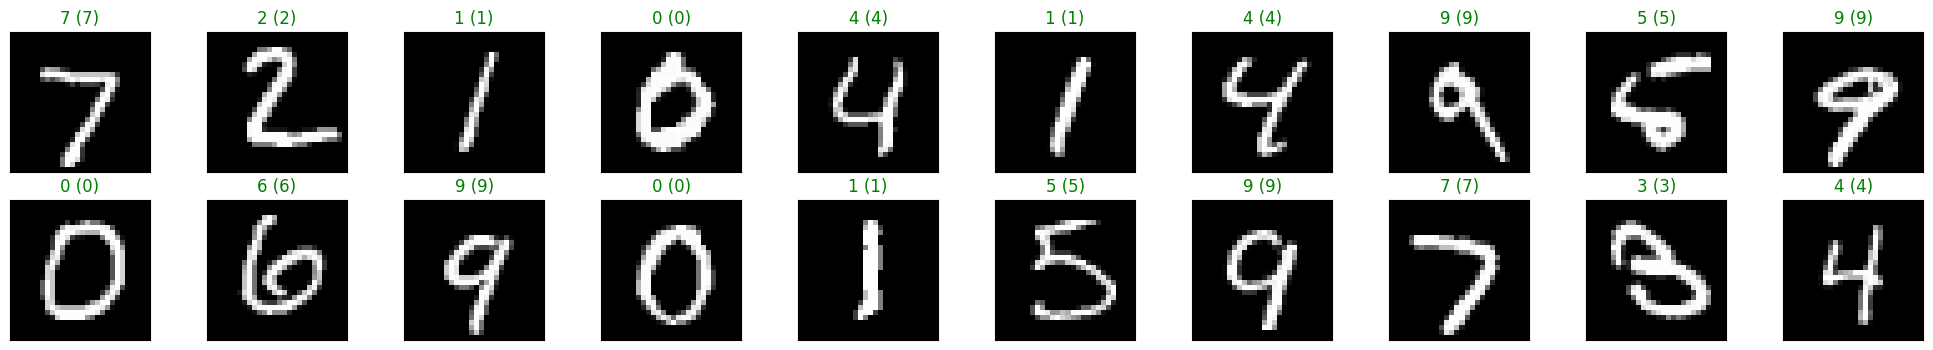

In [10]:
# obtain one batch of test images
dataiter = iter(test_loader)
images, labels = next(dataiter)

model.eval()
with torch.no_grad():
    output = model(images)
    _, preds = torch.max(output, 1)

images = images.numpy()

fig = plt.figure(figsize=(25, 4))
for idx in range(min(20, len(images))):
    ax = fig.add_subplot(2, 10, idx+1, xticks=[], yticks=[])
    ax.imshow(np.squeeze(images[idx]), cmap='gray')
    ax.set_title("{} ({})".format(
        preds[idx].item(),
        labels[idx].item()),
        color=("green" if preds[idx] == labels[idx] else "red")
    )